In [69]:
# Have all the imports configured here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score, auc, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xg
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as imbpipeline
import joblib as jb

Benchmarking:
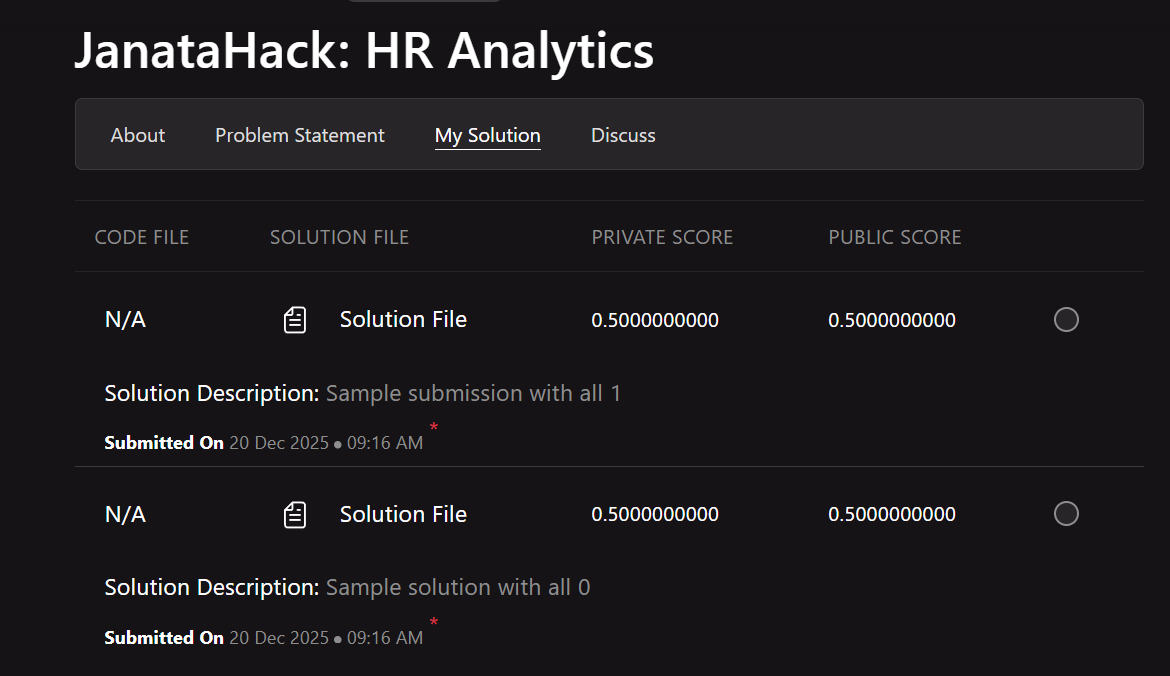

In [4]:
train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18359 entries, 0 to 18358
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             18359 non-null  int64  
 1   city                    18359 non-null  object 
 2   city_development_index  18359 non-null  float64
 3   gender                  14261 non-null  object 
 4   relevent_experience     18359 non-null  object 
 5   enrolled_university     18017 non-null  object 
 6   education_level         17902 non-null  object 
 7   major_discipline        15521 non-null  object 
 8   experience              18300 non-null  object 
 9   company_size            13580 non-null  object 
 10  company_type            13320 non-null  object 
 11  last_new_job            17992 non-null  object 
 12  training_hours          18359 non-null  int64  
 13  target                  18359 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [5]:
train_df.dtypes

,0
enrollee_id,int64
city,object
city_development_index,float64
gender,object
relevent_experience,object
enrolled_university,object
education_level,object
major_discipline,object
experience,object
company_size,object


In [6]:
train_df['gender'].value_counts()

,count
gender,
Male,12884
Female,1188
Other,189


In [7]:
train_df.head(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,23798,city_149,0.689,Male,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,106,0
1,29166,city_83,0.923,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,<10,Funded Startup,1,69,0
2,46,city_16,0.910,NaN,Has relevent experience,no_enrollment,Graduate,STEM,6,50-99,Public Sector,2,4,0


In [8]:
# List only columns which has NULL values in the data
train_df.columns[train_df.isna().any()]

Index(['gender', 'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_size', 'company_type', 'last_new_job'],
      dtype='object')

In [9]:
# List only columns which has NULL values in the data
train_df.isna().sum()[train_df.isna().sum() > 0]

,0
gender,4098
enrolled_university,342
education_level,457
major_discipline,2838
experience,59
company_size,4779
company_type,5039
last_new_job,367


In [10]:
train_df.isna().sum()[train_df.isna().sum() > 0].index.to_list()

['gender',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

In [11]:
# percentage of the missing data in %
(train_df.isna().sum()/train_df.shape[0])*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,0.000000
gender,22.321477
relevent_experience,0.000000
enrolled_university,1.862847
education_level,2.489242
major_discipline,15.458358
experience,0.321368
company_size,26.030830


In [12]:
(train_df.isna().sum()/len(train_df))*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,0.000000
gender,22.321477
relevent_experience,0.000000
enrolled_university,1.862847
education_level,2.489242
major_discipline,15.458358
experience,0.321368
company_size,26.030830


In [13]:
not_null_cols=train_df.columns[train_df.isna().any()]
not_null_cols

Index(['gender', 'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_size', 'company_type', 'last_new_job'],
      dtype='object')

In [14]:
((train_df[not_null_cols].isna().sum()/len(train_df))*100).sort_values(ascending=False)

,0
company_type,27.447029
company_size,26.030830
gender,22.321477
major_discipline,15.458358
education_level,2.489242
last_new_job,1.999020
enrolled_university,1.862847
experience,0.321368


In [15]:
# No deuplicatedin the train dataset
train_df.duplicated().sum()

np.int64(0)

In [16]:
train_df['target'].value_counts()

,count
target,
0,15934
1,2425


In [17]:
train_df.target.value_counts(), train_df.target.value_counts(normalize=True)

(target
 0    15934
 1     2425
 Name: count, dtype: int64,
 target
 0    0.867912
 1    0.132088
 Name: proportion, dtype: float64)

Both train_df['target'].value_counts() and train_df.target.value_counts() achieve the same result in this specific instance. However, there's a general preference for train_df['target'] (bracket notation) over train_df.target (dot notation) for several reasons:

**Flexibility**: Bracket notation works for all column names, including those with spaces, special characters, or names that are not valid Python identifiers (e.g., df['column with spaces']). Dot notation only works for column names that are valid Python identifiers.

**Ambiguity**: If a column name happens to be the same as a DataFrame method or attribute (e.g., df.count), using dot notation can lead to unexpected behavior as it will access the method/attribute instead of the column. Bracket notation avoids this ambiguity.

**Variable Column Name**s: If you need to access a column whose name is stored in a variable, you must use bracket notation (e.g., col_name = 'target'; train_df[col_name]).

While dot notation is more concise and often used for convenience when you're sure of the column names and their validity, bracket notation is generally considered the more robust and recommended approach in professional settings to prevent potential errors and ensure code readability and maintainability.

<Axes: xlabel='target'>

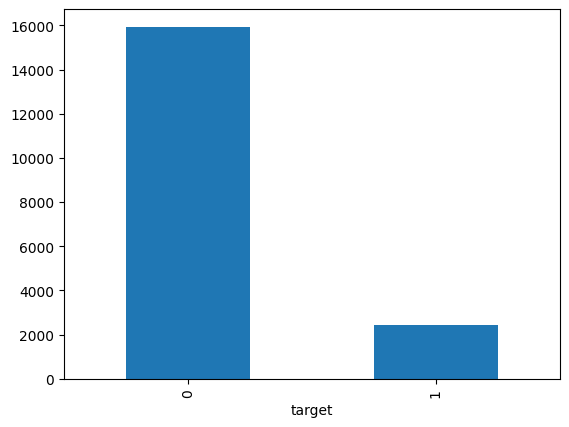

In [18]:
# check for target balance
train_df['target'].value_counts().plot(kind='bar')

Data is very much imbalanced with respecct to the target variaible

In [19]:
# find unique values in each columns
train_df.nunique()

,0
enrollee_id,18359
city,123
city_development_index,93
gender,3
relevent_experience,2
enrolled_university,3
education_level,5
major_discipline,6
experience,22
company_size,8


In [20]:
target_col=['target']
ignore_cols=['enrollee_id']


In [21]:
# Print unique values of each columns
for rec in train_df.drop(columns=ignore_cols).columns:
  print(rec)
  print(train_df[rec].unique())

city
['city_149' 'city_83' 'city_16' 'city_64' 'city_100' 'city_21' 'city_114'
 'city_103' 'city_97' 'city_160' 'city_65' 'city_90' 'city_75' 'city_136'
 'city_159' 'city_67' 'city_28' 'city_10' 'city_73' 'city_76' 'city_104'
 'city_27' 'city_30' 'city_61' 'city_99' 'city_41' 'city_142' 'city_9'
 'city_116' 'city_128' 'city_74' 'city_69' 'city_1' 'city_176' 'city_40'
 'city_123' 'city_152' 'city_165' 'city_89' 'city_36' 'city_44' 'city_46'
 'city_45' 'city_134' 'city_93' 'city_180' 'city_162' 'city_84' 'city_138'
 'city_173' 'city_19' 'city_71' 'city_158' 'city_23' 'city_102' 'city_105'
 'city_91' 'city_11' 'city_13' 'city_57' 'city_20' 'city_14' 'city_37'
 'city_115' 'city_50' 'city_167' 'city_12' 'city_143' 'city_126' 'city_77'
 'city_101' 'city_150' 'city_179' 'city_107' 'city_175' 'city_146'
 'city_98' 'city_166' 'city_118' 'city_129' 'city_127' 'city_24' 'city_81'
 'city_26' 'city_139' 'city_94' 'city_70' 'city_145' 'city_157' 'city_111'
 'city_78' 'city_80' 'city_33' 'city_7' 'ci

<Axes: xlabel='training_hours', ylabel='Count'>

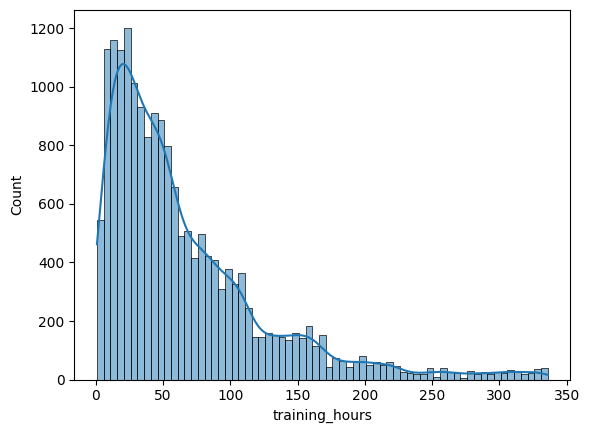

In [22]:
sns.histplot(train_df['training_hours'], kde=True) # right skewed

<Axes: xlabel='training_hours', ylabel='Density'>

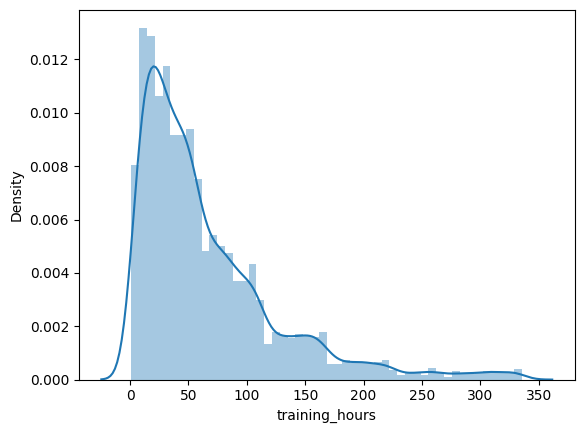

In [23]:
sns.distplot(train_df['training_hours'])

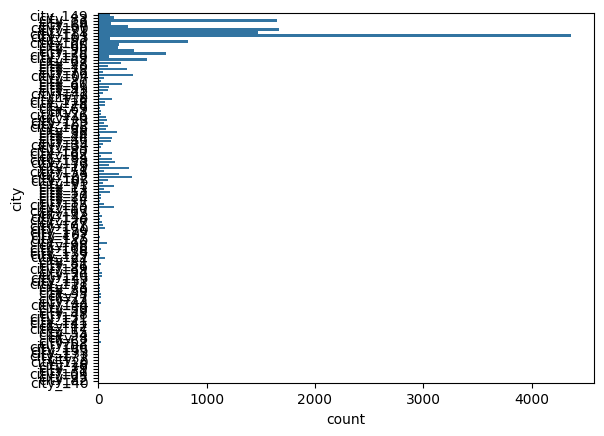

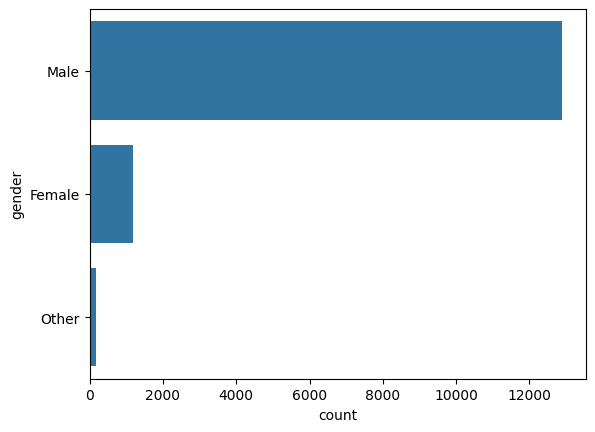

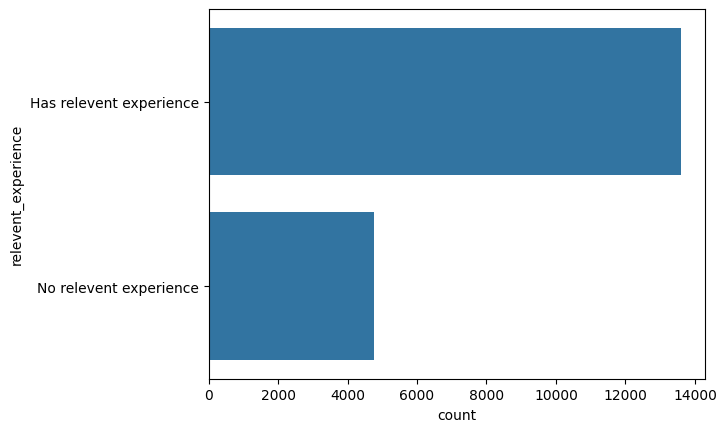

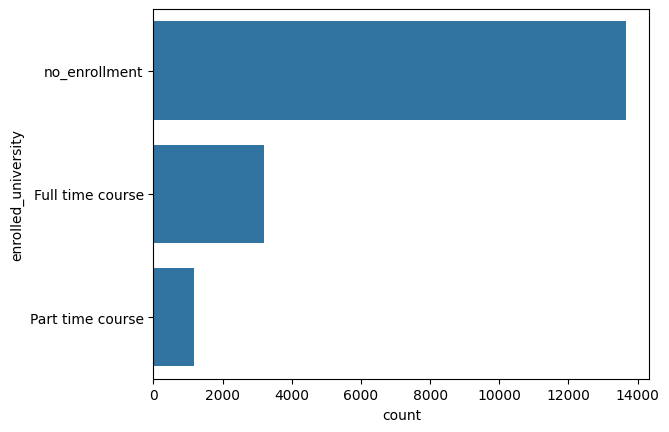

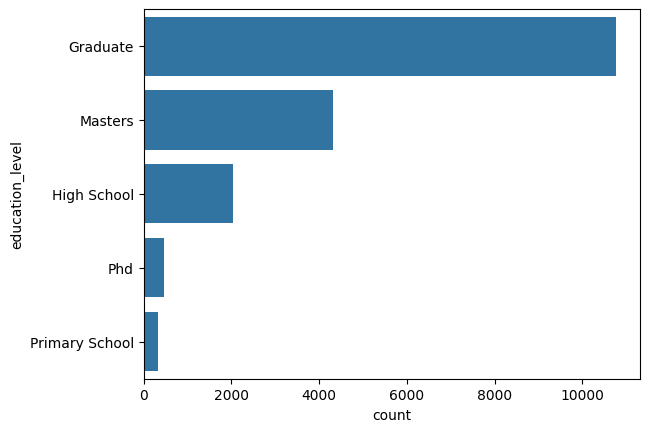

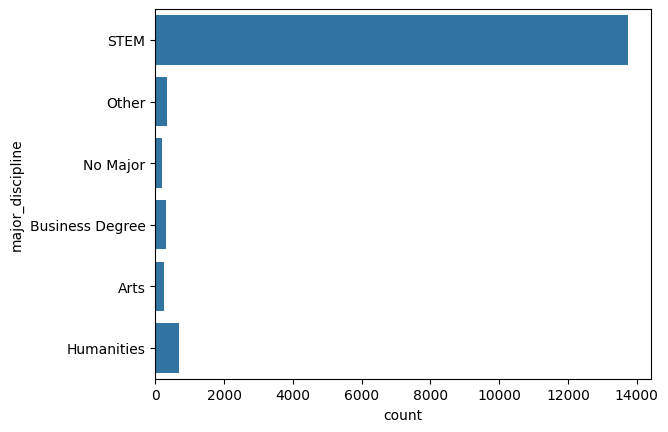

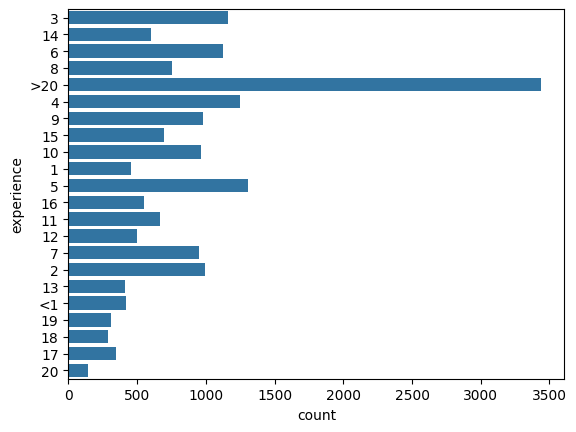

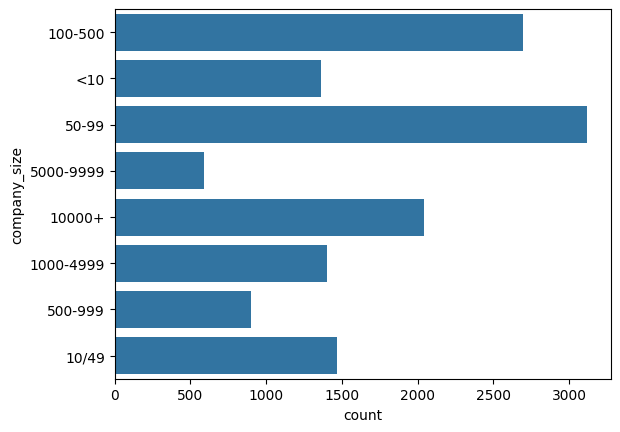

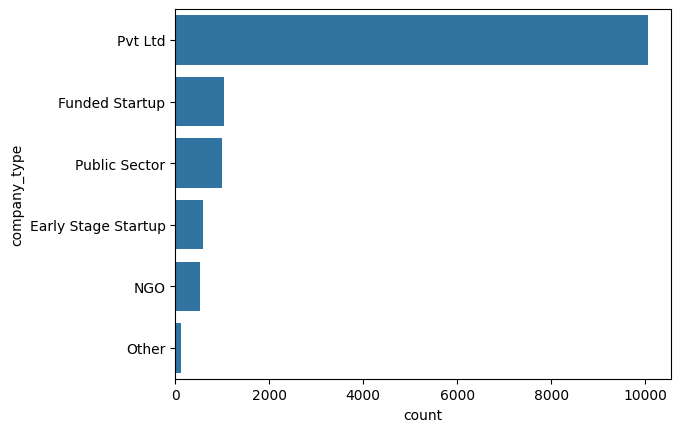

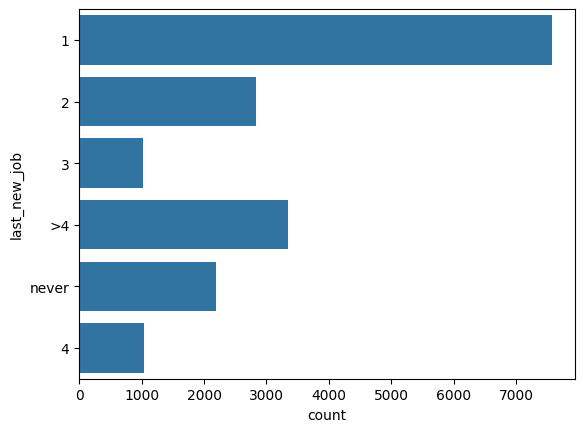

In [24]:
# visualize each column in a sns chart
for rec in train_df.select_dtypes(include='object').columns:
  sns.countplot(train_df[rec])
  plt.show()

<Axes: ylabel='city'>

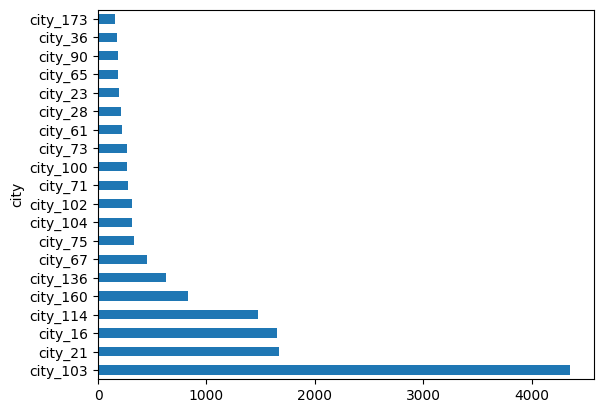

In [25]:
# City column is very clumpsy. Visualize the chart only with first 20 largest values
train_df['city'].value_counts().nlargest(20).plot(kind='barh')

In [26]:
# segreegating into the columns into numerical and categorical
numerical_cols=train_df.select_dtypes(exclude='object').columns.to_list()
categorical_cols=train_df.select_dtypes(include='object').columns.to_list()
numerical_cols.remove('enrollee_id')

In [27]:
numerical_cols

['city_development_index', 'training_hours', 'target']

In [28]:
ignore_cols

['enrollee_id']

In [29]:
numerical_cols_without_target = numerical_cols.copy()
numerical_cols_without_target.remove('target')

In [30]:
numerical_cols

['city_development_index', 'training_hours', 'target']

In [31]:
train_df[numerical_cols].corr()

,city_development_index,training_hours,target
city_development_index,1.000000,-0.006193,-0.135700
training_hours,-0.006193,1.000000,-0.004735
target,-0.135700,-0.004735,1.000000


In [32]:
categorical_pipeline=Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('categorical_encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

numerical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('numerical_transformer', StandardScaler())
    ]
)

In [33]:
preprocessing = ColumnTransformer(
    transformers=[
        ('categorical_pipeline', categorical_pipeline, categorical_cols),
        ('numerical_pipeline', numerical_pipeline, numerical_cols_without_target)
    ]
)

In [34]:
preprocessing

ColumnTransformer(transformers=[('categorical_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('categorical_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['city', 'gender', 'relevent_experience',
                                  'enrolled_university', 'education_level',
                                  'major_discipline', 'experience',
                                  'company_size', 'company_type',
                                  'last_new_job']),
                                ('numerical_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('numerical_transformer',
                                                  StandardScaler())]),
                                 ['city_development_index', 'training_hours'])])

In [35]:

model_pipeline=Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', xg.XGBClassifier())
    ]
)
"""

model_pipeline=Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', LogisticRegression())
    ]
)
"""

"\n\nmodel_pipeline=Pipeline(\n    steps=[\n        ('preprocessing', preprocessing),\n        ('model', LogisticRegression())\n    ]\n)\n"

In [36]:
model_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('categorical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('categorical_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'gender',
                                                   'relevent_experience',
                                                   'enrolled_university',
                                                   'education_level',
                                                   'major_discipline',
                                                   'experience', 'company_size',
                                                   'c...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [37]:
X=train_df.drop(columns=ignore_cols+target_col)
y=train_df[target_col]
train_x, val_x, train_y, val_y = train_test_split(X,y, test_size=0.2, random_state=42)

In [38]:
model_pipeline.fit(train_x, train_y)
y_train_pred = model_pipeline.predict(train_x)
train_accuracy_score = accuracy_score(train_y, y_train_pred)
print(train_accuracy_score)

0.8852046027098794


In [39]:
y_val_pred = model_pipeline.predict(val_x)
val_accuracy_score = accuracy_score(val_y, y_val_pred)
print(val_accuracy_score)

0.8622004357298475


In [40]:
model_pipeline.predict_proba(train_x)

array([[0.7884635 , 0.21153653],
       [0.93798846, 0.06201151],
       [0.82781476, 0.17218524],
       ...,
       [0.88547015, 0.11452988],
       [0.93627924, 0.06372079],
       [0.9327557 , 0.0672443 ]], dtype=float32)

In [41]:
model_pipeline.predict_proba(val_x)

array([[0.93398666, 0.06601334],
       [0.8515972 , 0.14840281],
       [0.9791424 , 0.02085757],
       ...,
       [0.9345849 , 0.06541506],
       [0.95025957, 0.04974043],
       [0.92331946, 0.07668054]], dtype=float32)

In [42]:
print(confusion_matrix(train_y, y_train_pred))

[[12745    17]
 [ 1669   256]]


In [43]:
print(classification_report(train_y, y_train_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     12762
           1       0.94      0.13      0.23      1925

    accuracy                           0.89     14687
   macro avg       0.91      0.57      0.59     14687
weighted avg       0.89      0.89      0.85     14687



In [44]:
print(classification_report(val_y, y_val_pred))

              precision    recall  f1-score   support

           0       0.87      0.99      0.93      3172
           1       0.38      0.02      0.04       500

    accuracy                           0.86      3672
   macro avg       0.63      0.51      0.48      3672
weighted avg       0.80      0.86      0.80      3672



In [45]:
def model_eval_function(train_x, train_y, val_x, val_y, model_pipeline):
  predicted_train_values = model_pipeline.predict(train_x)
  predicted_val_values = model_pipeline.predict(val_x)

  print(f'Train accuracy Score: {accuracy_score(train_y, predicted_train_values)}')
  print(f'Validation accuracy Score: {accuracy_score(val_y, predicted_val_values)}')

  print(f'Train Confusion Matrix: \n{confusion_matrix(train_y, predicted_train_values)}')
  print(f'Validation Confusion Matrix: \n{confusion_matrix(val_y, predicted_val_values)}')
  print(f'Train Classification Report: \n{classification_report(train_y, predicted_train_values)}')
  print(f'Validation Classification Report: \n{classification_report(val_y, predicted_val_values)}')
  print(f'Train ROC AUC Score: {roc_auc_score(train_y, model_pipeline.predict_proba(train_x)[:,1])}')
  print(f'Validation ROC AUC Score: {roc_auc_score(val_y, model_pipeline.predict_proba(val_x)[:,1])}')

In [46]:
model_eval_function(train_x, train_y, val_x, val_y, model_pipeline)

Train accuracy Score: 0.8852046027098794
Validation accuracy Score: 0.8622004357298475
Train Confusion Matrix: 
[[12745    17]
 [ 1669   256]]
Validation Confusion Matrix: 
[[3156   16]
 [ 490   10]]
Train Classification Report: 
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     12762
           1       0.94      0.13      0.23      1925

    accuracy                           0.89     14687
   macro avg       0.91      0.57      0.59     14687
weighted avg       0.89      0.89      0.85     14687

Validation Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      3172
           1       0.38      0.02      0.04       500

    accuracy                           0.86      3672
   macro avg       0.63      0.51      0.48      3672
weighted avg       0.80      0.86      0.80      3672

Train ROC AUC Score: 0.892776627854202
Validation ROC AUC Score: 0.59809804539722

In [47]:
test_prediction = model_pipeline.predict_proba(test_df.drop(columns=ignore_cols))[:,1]

In [48]:
test_prediction

array([0.7268911 , 0.12792134, 0.30490035, ..., 0.07788794, 0.14618959,
       0.29313442], dtype=float32)

In [49]:
submission_df = pd.DataFrame({'enrollee_id': test_df['enrollee_id'], 'target': test_prediction})
submission_df.to_csv('submission_XGBoost_without_undersampling_proba.csv', index=False)

In [50]:
submission_df

,enrollee_id,target
0,16548,0.726891
1,12036,0.127921
2,11061,0.304900
3,5032,0.043964
4,17599,0.041998
...,...,...
15016,11308,0.135866
15017,14612,0.160359
15018,33346,0.077888
15019,14506,0.146190


In [63]:
grid_params=[
    {
        'model': [LogisticRegression()],
        'model__penalty': ['l1', 'l2', 'elasticnet', None],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'model': [xg.XGBClassifier()],
        'model__n_estimators': [100, 200, 300, 400, 500],
        'model__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'model__max_depth': [3, 4, 5, 6, 7]
    }
]

In [64]:
grid_1 = GridSearchCV(estimator=model_pipeline, param_grid=grid_params, cv=5, scoring='roc_auc')

In [65]:
under_sampler = RandomUnderSampler()
train_x_us, train_y_us = under_sampler.fit_resample(train_x, train_y)

In [66]:
grid_1.fit(train_x_us, train_y_us)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('categorical_pipeline',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('categorical_encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['city',
                                                                          'gender',
                                                                          'relevent_experience',
                                                                          'enrolled_university',
                                                                          'education_level',
                                                                          'major_discipline',
                                                                          'e...
                                                  max_cat_to_onehot=None,
                                                  max_delta_step=None,
                                                  max_depth=None,
                                                  max_leaves=None,
                                                  min_child_weight=None,
                                                  missing=nan,
                                                  monotone_constraints=None,
                                                  multi_strategy=None,
                                                  n_estimators=None,
                                                  n_jobs=None,
                                                  num_parallel_tree=None, ...)],
                          'model__learning_rate': [0.01, 0.1, 0.2, 0.3],
                          'model__max_depth': [3, 4, 5, 6, 7],
                          'model__n_estimators': [100, 200, 300, 400, 500]}],
             scoring='roc_auc')

In [67]:
grid_1.best_params_

{'model': LogisticRegression(), 'model__C': 0.01, 'model__penalty': 'l2'}

In [68]:
best_model = grid_1.best_estimator_
model_eval_function(train_x_us, train_y_us, val_x, val_y, best_model)

Train accuracy Score: 0.6228571428571429
Validation accuracy Score: 0.6633986928104575
Train Confusion Matrix: 
[[1329  596]
 [ 856 1069]]
Validation Confusion Matrix: 
[[2180  992]
 [ 244  256]]
Train Classification Report: 
              precision    recall  f1-score   support

           0       0.61      0.69      0.65      1925
           1       0.64      0.56      0.60      1925

    accuracy                           0.62      3850
   macro avg       0.63      0.62      0.62      3850
weighted avg       0.63      0.62      0.62      3850

Validation Classification Report: 
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      3172
           1       0.21      0.51      0.29       500

    accuracy                           0.66      3672
   macro avg       0.55      0.60      0.54      3672
weighted avg       0.80      0.66      0.71      3672

Train ROC AUC Score: 0.6613526733007252
Validation ROC AUC Score: 0.6291919924337958


In [70]:
jb.dump(best_model, 'best_model_HR_analysis.pkl')

['best_model_HR_analysis.pkl']

In [72]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 38.9 MB/s eta 0:00:00


In [74]:
train_df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [75]:
train_df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,23798,city_149,0.689,Male,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,106,0
1,29166,city_83,0.923,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,<10,Funded Startup,1,69,0
2,46,city_16,0.910,NaN,Has relevent experience,no_enrollment,Graduate,STEM,6,50-99,Public Sector,2,4,0
3,18527,city_64,0.666,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,50-99,Pvt Ltd,1,26,0
4,21751,city_100,0.887,NaN,No relevent experience,no_enrollment,Masters,STEM,8,NaN,NaN,2,88,1


In [84]:
testing_to_df = pd.DataFrame({'id':[1]})

In [85]:
%%writefile webview.py
import streamlit as st
import pandas as pd
import joblib as jb

st.title("HR job switch application")

train_df = pd.read_csv('train.csv')


# inputs
city = st.selectbox('City', train_df['city'].unique())
city_development_index = st.number_input('City Development Index', min_value=0.0, max_value=1.0, step=0.01)
gender = st.selectbox('Gender', train_df['gender'].unique())
relevent_experience = st.selectbox('Relevent Experience', train_df['relevent_experience'].unique())
enrolled_university = st.selectbox('Enrolled University', train_df['enrolled_university'].unique())
education_level     = st.selectbox('Education Level', train_df['education_level'].unique())
major_discipline    = st.selectbox('Major Discipline', train_df['major_discipline'].unique())
experience          = st.selectbox('Experience', train_df['experience'].unique())
company_size        = st.selectbox('Company Size', train_df['company_size'].unique())
company_type        = st.selectbox('Company Type', train_df['company_type'].unique())
last_new_job        = st.selectbox('Last New Job', train_df['last_new_job'].unique())
training_hours      = st.number_input('Training Hours', min_value=0, max_value=1000, step=1)

# load the model
model = jb.load('best_model_HR_analysis.pkl')

# form all inouts as a dataframe to be passed into model
input_df = pd.DataFrame({
    'city': [city],
    'city_development_index': [city_development_index],
    'gender': [gender],
    'relevent_experience': [relevent_experience],
    'enrolled_university': [enrolled_university],
    'education_level': [education_level],
    'major_discipline': [major_discipline],
    'experience': [experience],
    'company_size': [company_size],
    'company_type': [company_type],
    'last_new_job': [last_new_job],
    'training_hours': [training_hours]
})

#predict button
if st.button('Predict'):
  # Output
  target = model.predict(input_df)
  st.write(f'Target: {target[0]}')

Overwriting webview.py


In [88]:
!pip install -qqq pyngrok

In [89]:
# Install pyngrok (if not already installed)
#!pip install -qqq pyngrok

# Kill any existing processes on port 8501 to avoid conflicts
!kill $(lsof -t -i:8501) 2>/dev/null || true

from pyngrok import ngrok
import subprocess
import time
import os

# Terminate any open ngrok tunnels from previous runs
ngrok.kill()

# IMPORTANT: For stable long-term tunnels, you might need to add your ngrok authtoken.
# You can get one from https://dashboard.ngrok.com/auth/your-authtoken
ngrok.set_auth_token("378hd2i3PcBJghX044GOzeK2bv1_6H3HQFqUjxamS6qNJow8p") # Uncomment and replace if you have one

# Start ngrok tunnel for port 8501 (where Streamlit will run)
public_url = ngrok.connect(addr="8501", proto="http")
print(f"Streamlit App URL: {public_url}")

# Define a log file for Streamlit's output
streamlit_log_file = "streamlit_output.log"

# Start Streamlit in the background, redirecting its output to the log file.
# Using 'nohup' and 'preexec_fn=os.setpgrp' helps ensure the process continues
# even if the Colab cell loses focus or completes its execution.
# '--server.headless true' prevents Streamlit from trying to open a browser window on the server.
# '--browser.gatherUsageStats false' disables sending usage statistics.
with open(streamlit_log_file, "w") as f:
    subprocess.Popen(['nohup', 'streamlit', 'run', 'webview.py', '--server.port', '8501', '--server.headless', 'true', '--browser.gatherUsageStats', 'false'],
                     stdout=f, stderr=f, preexec_fn=os.setpgrp)

print(f"Streamlit logs are being written to: {streamlit_log_file}")
print("Please wait a few seconds for the Streamlit app to start completely.")
time.sleep(10) # Give Streamlit some time to initialize

print("\nIf the Streamlit app doesn't load or shows an error, you can check the logs for details:")
print(f"!cat {streamlit_log_file}")

Streamlit App URL: NgrokTunnel: "https://viably-subchorioid-amir.ngrok-free.dev" -> "http://localhost:8501"
Streamlit logs are being written to: streamlit_output.log
Please wait a few seconds for the Streamlit app to start completely.

If the Streamlit app doesn't load or shows an error, you can check the logs for details:
!cat streamlit_output.log
